In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join
from collections import defaultdict
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import LinearRegression

import logging
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('euclid_stylesheet_v2.mplstyle')
mpl.rcParams['figure.dpi'] = 300

In [2]:
mdir = './saved_models'


def r2logm(r):
    # see preprocessing.ipynb for this measurement
    coef = 0.36752
    intercept = -5.30640
    return (np.log10(r)-intercept)/coef

In [3]:
datanames = ['wC50', 'wC100', 'dC50', 'dC100']
runnames = ['base', 'gals_nle', 'summ_nle', 'gnn_npe']
modelnames = ['msig', 'pamico', 'mamp', 'gals_nle', 'summ_nle', 'gnn_npe']
Nfolds = 10
folds = np.arange(Nfolds)

datatitles = dict(
    wC50='Wide $50\%$',
    wC100='Wide $100\%$',
    dC50='Deep $50\%$',
    dC100='Deep $100\%$'
)
modeltitles = dict(
    msig='$M$--$\sigma$',
    pamico=r'$M$--$\lambda_{\rm spec}$',
    mamp='MAMPOSSt',
    gals_nle='Galaxy-Net',
    summ_nle='Summary-Net',
    gnn_npe='Graph-Net',
    true='True',
    prior='Prior',
    dummy='Dummy'
)

In [4]:
from scipy.stats import skewnorm
from scipy.optimize import minimize


def fit_skewed_normal(p16, p50, p84):
    target_percentiles = [0.16, 0.50, 0.84]
    observed_values = [p16, p50, p84]

    def objective(params):
        loc, scale, alpha = params
        if scale <= 0:
            return np.inf
        skewed_gaussian = skewnorm(alpha, loc=loc, scale=scale)
        calculated_values = skewed_gaussian.ppf(target_percentiles)
        return np.sum((calculated_values - observed_values) ** 2)

    initial_guess = [p50, (p84 - p16) / 2, 0.5]
    result = minimize(objective, initial_guess)
    loc, scale, alpha = result.x
    return skewnorm(alpha, loc=loc, scale=scale)

In [5]:
# load train/test
header = 'APR24'
datadir = './data/processed'

theta, fold, ids, richs, zclus, Ngal = {}, {}, {}, {}, {}, {}
for d in datanames:
    dirpath = join(datadir, f'{header}{d}')
    print('Loading:', dirpath)
    theta[d] = np.load(join(dirpath, 'theta_batch.npy'))
    fold[d] = np.load(join(dirpath, 'folds_batch.npy'))
    ids[d] = np.load(join(dirpath, 'ids_batch.npy'))
    metas = np.load(join(dirpath, 'metas_batch.npy'))
    zclus[d] = metas[:, 3]  # cluster photometric redshift
    richs[d] = metas[:, 1]  # sum of AMICO photometry
    Ngal[d] = np.load(join(dirpath, 'x_sum.npy'))[:, -1]

Ndata = {d: len(theta[d]) for d in datanames}
print(Ndata)

Loading: ./data/processed/APR24wC50
Loading: ./data/processed/APR24wC100
Loading: ./data/processed/APR24dC50
Loading: ./data/processed/APR24dC100
{'wC50': 840, 'wC100': 907, 'dC50': 1998, 'dC100': 2014}


In [6]:
Nsamp = 100
preds = defaultdict(dict)
for d in datanames:
    for r in runnames:
        # setup
        if r == 'base':
            preds[d]['msig'] = np.ones((Ndata[d], 2))*np.nan
            preds[d]['pamico'] = np.ones((Ndata[d], 2))*np.nan
        else:
            preds[d][r] = np.full((Ndata[d], Nsamp, 1), np.nan)

        # load
        for f in folds:
            if r == 'gnn_npe':
                dirname = f'oct02_{r}_{d}_f{f}'
            else:
                dirname = f'apr24_{r}_{d}_f{f}'
            if r == 'base':
                # Msig
                samplefile = join(mdir, dirname, 'msig.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['msig'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['msig'][:, 1], place_ids, s['std'])

                # Pamico
                samplefile = join(mdir, dirname, 'Pamico.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['pamico'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['pamico'][:, 1], place_ids, s['std'])

            else:
                # ML models
                samplefile = join(mdir, dirname, 'posterior_samples.npy')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                s = np.swapaxes(s, 0, 1)
                s = s[:, :Nsamp]  # subsample if necessary
                preds[d][r][fold[d] == f] = s

In [7]:
# load mamposst

mamnames = {
    'wC50': 'wide50', 'wC100': 'wide100', 'dC50': 'deep50', 'dC100': 'deep100'
}
modeldir = './saved_models/mamposst_newprior_dec1824/'

for k, v in mamnames.items():
    isamp = pd.read_csv(join(modeldir, f'result_MockFS_NewAMICO_{v}.dat'),
                        delimiter=' ', skipinitialspace=True)
    isamp['id'] = isamp['#ClusterID'].astype(int)
    # convert r200 to logm
    for c in isamp.columns:
        if 'r200' not in c:
            continue
        isamp['logm'+c[4:]] = r2logm(isamp[c])

    # put in preds
    preds[k]['mamp'] = np.ones((Ndata[k], 5))*np.nan
    place_ids = np.searchsorted(ids[k], isamp['id'].values)
    mask = place_ids < Ndata[k]
    _s = isamp[['logmlow(68)', 'logmup(68)', 'logmlow(95)',
                'logmup(95)', 'logmMAM']].values
    preds[k]['mamp'][place_ids[mask]] = _s[mask]

In [8]:
# calculate percentiles from predictions
q = 100*np.array([0.16, 0.84, 0.5, 0.025, 0.975])
percs = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        if m == 'msig' or m == 'pamico':
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0]-t_[:, 1], t_[:, 0]+t_[:, 1], t_[:, 0],
                    t_[:, 0]-2*t_[:, 1], t_[:, 0]+2*t_[:, 1]],
                axis=1).T
        elif m == 'mamp':
            if m not in preds[d]:
                continue
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0], t_[:, 1], t_[:, 4], t_[:, 2], t_[:, 3]],
                axis=1).T
        else:
            t_ = preds[d][m]
            percs[d][m] = np.percentile(t_, q, axis=1)[..., 0]
# percs is of shape (5, Ndata)
# dim 0 is of order [16, 84, 50, 2.5, 97.5]

In [9]:
# Compute quality control
def quality_control(percs):
    # checks if we have a reasonable median prediction
    # checks if we're not missing a prediction (not nan)
    med = percs[2]
    mask = (med > 12) & (med < 16)

    err = (percs[1] - percs[0])/2
    mask &= err < 1
    return mask


qc = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        qc[d][m] = quality_control(percs[d][m])

In [10]:
# Remove Ngal < 3
for d in datanames:
    mask = Ngal[d] >= 3

    theta[d] = theta[d][mask]
    fold[d] = fold[d][mask]
    ids[d] = ids[d][mask]
    richs[d] = richs[d][mask]
    zclus[d] = zclus[d][mask]
    Ngal[d] = Ngal[d][mask]
    Ndata[d] = len(theta[d])

    for m in modelnames:
        if m not in percs[d]:
            continue
        preds[d][m] = preds[d][m][mask]
        percs[d][m] = percs[d][m][:, mask]
        qc[d][m] = qc[d][m][mask]

# Calibration-assumption checks (dC100)

Tests the four assumptions of v7's forward-Gaussian calibration channel
$\mu = a + b_{\rm fwd}(m_{\rm true}-m_{\rm ref}) + \eta,\ \eta\sim N(0,\omega_0^2+\kappa^2\sigma^2)$
for the `msig`, `mamp`, and `gnn_npe` mass models:

1. **Linearity** -- is $\mu$ vs $m_{\rm true}$ a straight line? (quadratic term,
   residual-vs-mass)
2. **z-dependence** -- does the calibration residual drift with redshift? (the
   channel has no z term)
3. **Gaussianity** -- are the posteriors symmetric? (per-cluster skew); is the
   standardized pull $(m_{\rm true}-\mu)/\sigma \sim N(0,1)$?
4. **Scatter structure** -- does the residual scatter track the reported width
   $\sigma_i$ (the $\omega_0^2+\kappa^2\sigma^2$ form)?

`m_ref = 13.78`, `z0 = 0.82`.

In [ ]:
from scipy.stats import skew as sstat_skew

m_ref, z0 = 13.78, 0.82


def get_summaries(d, m, Nsamp=100):
    """Per-cluster posterior summaries (mu, sigma, skew) + truth/redshift."""
    mtrue = theta[d][:, 0]
    z = zclus[d]
    if m in ['msig', 'pamico']:
        mu, sigma = preds[d][m][:, 0], preds[d][m][:, 1]
        skw = np.zeros_like(mu)                    # Gaussian by construction
    elif m == 'mamp':
        ps = preds[d][m]
        p16, p84, p50 = ps[:, 0], ps[:, 1], ps[:, 4]
        samps = np.array([
            fit_skewed_normal(p16[i], p50[i], p84[i]).rvs(Nsamp)
            if not np.isnan(p16[i]) else np.full(Nsamp, np.nan)
            for i in range(len(p16))])
        mu, sigma = np.nanmean(samps, 1), np.nanstd(samps, 1)
        skw = sstat_skew(samps, axis=1, nan_policy='omit')
    else:                                          # gnn_npe and other ML
        samps = preds[d][m][..., 0]
        mu, sigma = samps.mean(1), samps.std(1)
        skw = sstat_skew(samps, axis=1)
    mask = qc[d][m]
    return dict(mu=mu[mask], sigma=sigma[mask], mtrue=mtrue[mask],
                z=z[mask], skew=np.asarray(skw)[mask])


def binned(x, y, nbins=12, fn=np.std):
    """fn of y in nbins quantile bins of x; returns bin centers + values."""
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    edges = np.unique(np.quantile(x, np.linspace(0, 1, nbins + 1)))
    cen, val = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (x >= lo) & (x <= hi)
        if sel.sum() < 5:
            continue
        cen.append(x[sel].mean())
        val.append(fn(y[sel]))
    return np.array(cen), np.array(val)

In [ ]:
def diagnose(d, m):
    S = get_summaries(d, m)
    mu, sigma, mtrue, z, skw = (S['mu'], S['sigma'], S['mtrue'], S['z'],
                                S['skew'])
    g = np.isfinite(mu) & np.isfinite(sigma) & np.isfinite(mtrue)
    mu, sigma, mtrue, z, skw = mu[g], sigma[g], mtrue[g], z[g], skw[g]
    zeta = np.log10((1 + z) / (1 + z0))

    # forward calibration: linear + quadratic fits of mu on (mtrue - m_ref)
    dm = mtrue - m_ref
    X1 = np.vstack([np.ones_like(dm), dm]).T
    a_, b_ = np.linalg.lstsq(X1, mu, rcond=None)[0]
    resid = mu - (a_ + b_*dm)
    c0, c1, c2 = np.linalg.lstsq(
        np.vstack([np.ones_like(dm), dm, dm**2]).T, mu, rcond=None)[0]
    zc = np.polyfit(zeta, resid, 1)            # residual drift with redshift
    pull = (mtrue - mu) / sigma

    fig, ax = plt.subplots(2, 3, figsize=(15, 8))

    # (1) forward calibration scatter + linear/quadratic
    xs = np.linspace(mtrue.min(), mtrue.max(), 100)
    ax[0, 0].plot(mtrue, mu, '.', alpha=0.15, color='C0')
    ax[0, 0].plot(xs, a_ + b_*(xs - m_ref), 'C3', label=f'linear b={b_:.2f}')
    ax[0, 0].plot(xs, c0 + c1*(xs-m_ref) + c2*(xs-m_ref)**2, 'C2--',
                  label=f'quad c2={c2:.2f}')
    ax[0, 0].plot(xs, xs, 'k:', label='1:1')
    ax[0, 0].set(xlabel=r'$m_{\rm true}$', ylabel=r'$\mu$ (post. mean)',
                 title='(1) forward calibration')
    ax[0, 0].legend(fontsize=7)

    # (2) nonlinearity: binned mean residual vs mass
    ax[0, 1].plot(mtrue, resid, '.', alpha=0.1, color='C0')
    cb, vb = binned(mtrue, resid, fn=np.mean)
    ax[0, 1].plot(cb, vb, 'C3o-')
    ax[0, 1].axhline(0, color='k', lw=0.8)
    ax[0, 1].set(xlabel=r'$m_{\rm true}$', ylabel='lin. residual',
                 title='(2) nonlinearity (binned mean)')

    # (3) z-dependence: residual vs z
    ax[0, 2].plot(z, resid, '.', alpha=0.1, color='C0')
    cz, vz = binned(z, resid, fn=np.mean)
    ax[0, 2].plot(cz, vz, 'C3o-')
    ax[0, 2].axhline(0, color='k', lw=0.8)
    ax[0, 2].set(xlabel='z', ylabel='lin. residual',
                 title=f'(3) z-drift (slope/zeta={zc[0]:.2f})')

    # (4) pull histogram vs N(0,1)
    pg = pull[np.isfinite(pull)]
    ax[1, 0].hist(pg, bins=40, density=True, alpha=0.6, color='C0')
    xx = np.linspace(-4, 4, 100)
    ax[1, 0].plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), 'C3')
    ax[1, 0].set(xlim=(-4, 4), xlabel=r'$(m_{\rm true}-\mu)/\sigma$',
                 title=f'(4) pull: mean={pg.mean():.2f}, std={pg.std():.2f}')

    # (5) scatter structure: residual std vs reported sigma
    cs, vs = binned(sigma, resid, fn=np.std)
    ax[1, 1].plot(cs, vs, 'C3o-', label='resid std in bin')
    lim = [min(cs.min(), vs.min()), max(cs.max(), vs.max())]
    ax[1, 1].plot(lim, lim, 'k:', label=r'$\omega=\sigma$ (kappa=1)')
    ax[1, 1].set(xlabel=r'reported $\sigma$', ylabel='actual resid std',
                 title='(5) scatter structure')
    ax[1, 1].legend(fontsize=7)

    # (6) posterior skew
    sg = skw[np.isfinite(skw)]
    ax[1, 2].hist(sg, bins=40, alpha=0.6, color='C0')
    ax[1, 2].axvline(0, color='k')
    ax[1, 2].axvline(np.median(sg), color='C3', ls='--')
    ax[1, 2].set(xlabel='per-cluster posterior skew',
                 title=f'(6) skew (median={np.median(sg):.2f})')

    fig.suptitle(f'{d} / {m}  (N={len(mu)})', fontsize=12)
    fig.tight_layout()

    return dict(model=m, N=len(mu), b_fwd=b_, quad_c2=c2, z_slope=zc[0],
                pull_mean=pg.mean(), pull_std=pg.std(),
                skew_med=float(np.median(sg)))

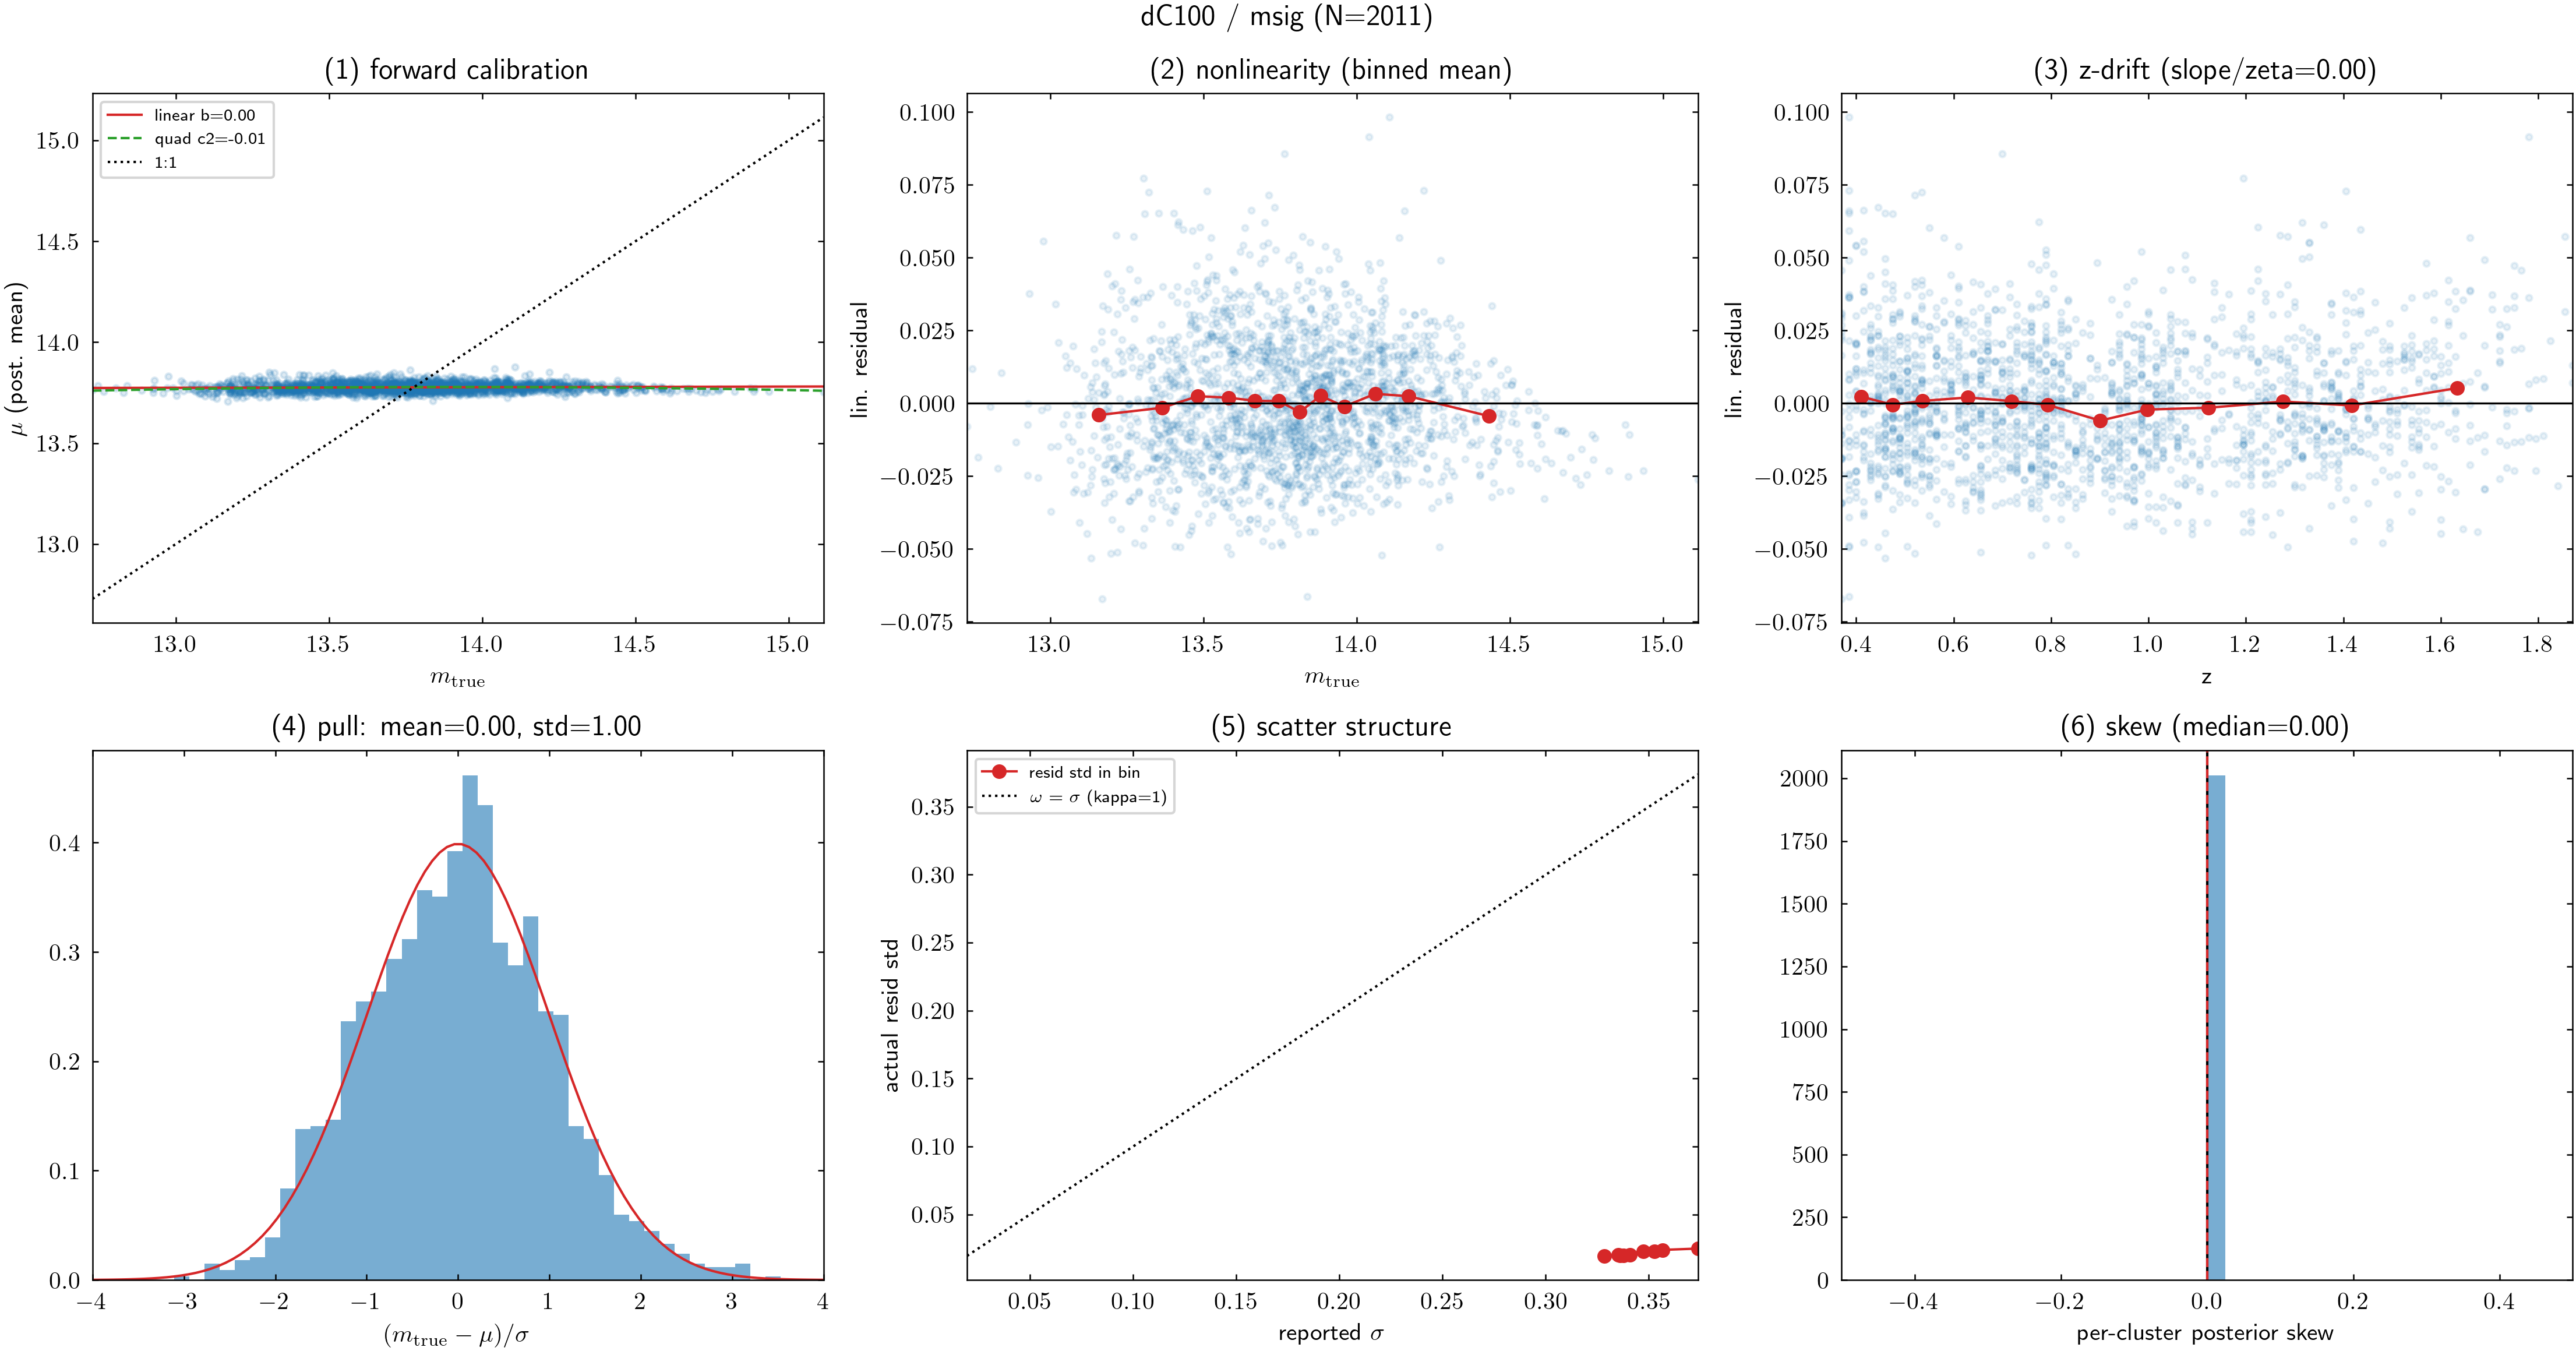

In [13]:
results = {}
results['msig'] = diagnose('dC100', 'msig')

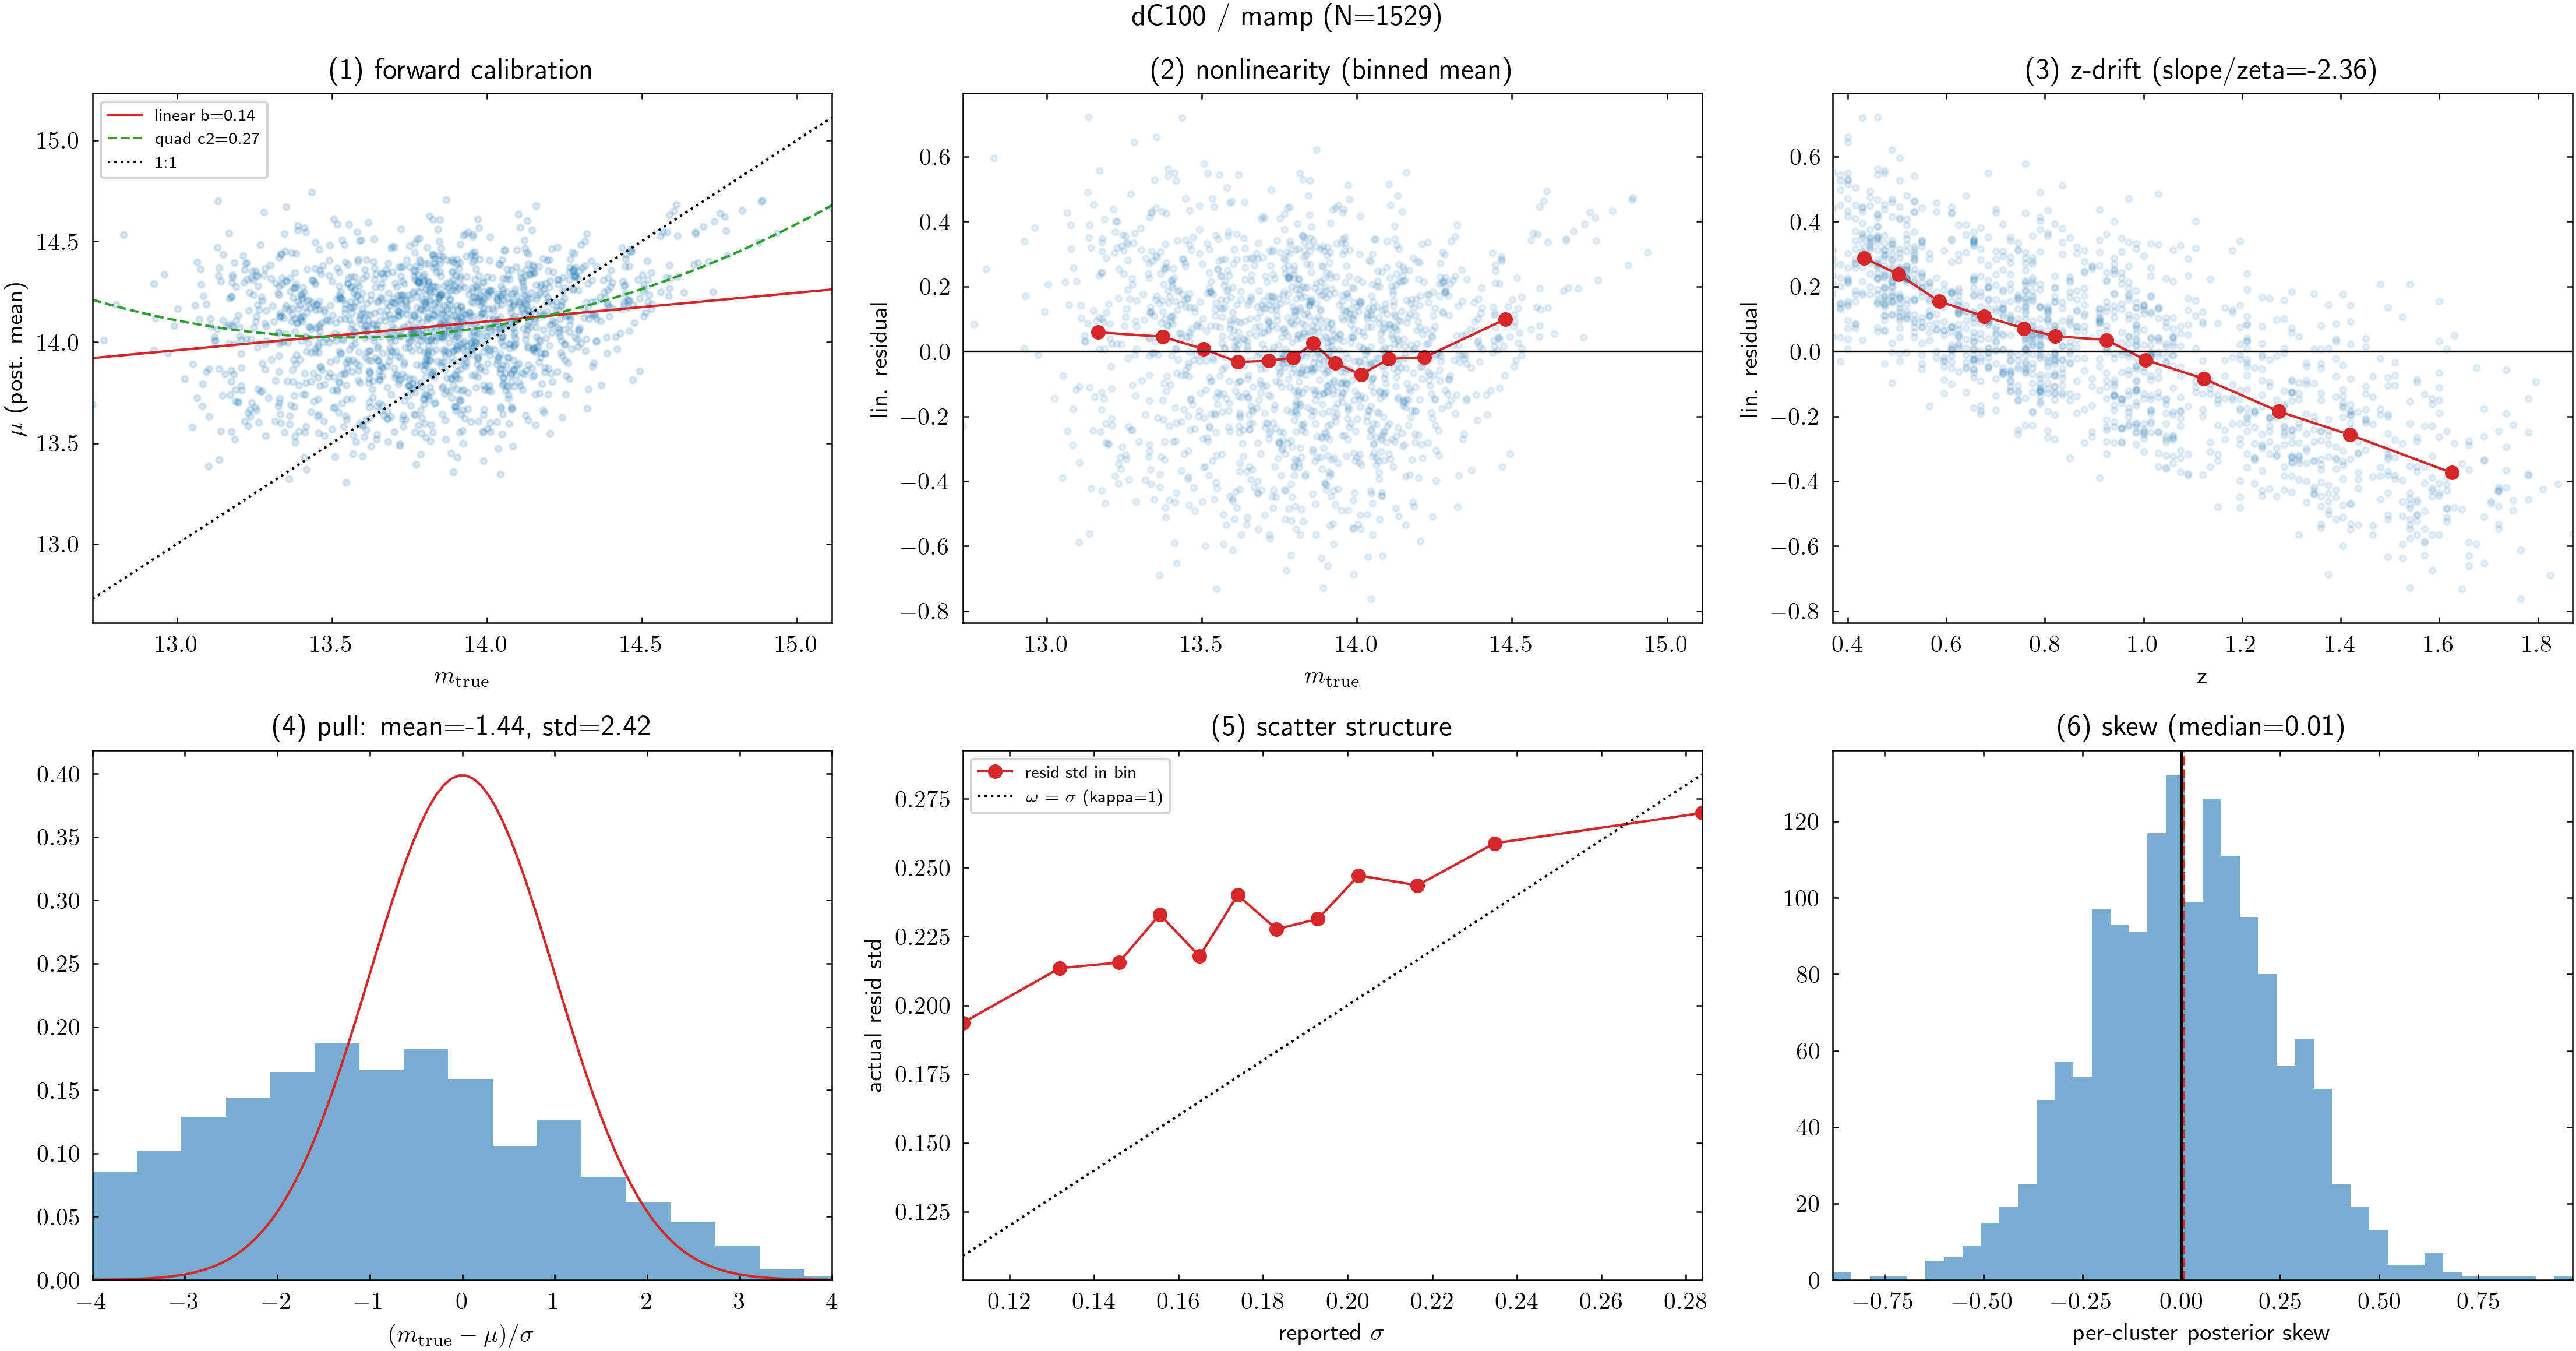

In [14]:
results['mamp'] = diagnose('dC100', 'mamp')

In [ ]:
results['gnn_npe'] = diagnose('dC100', 'nle')

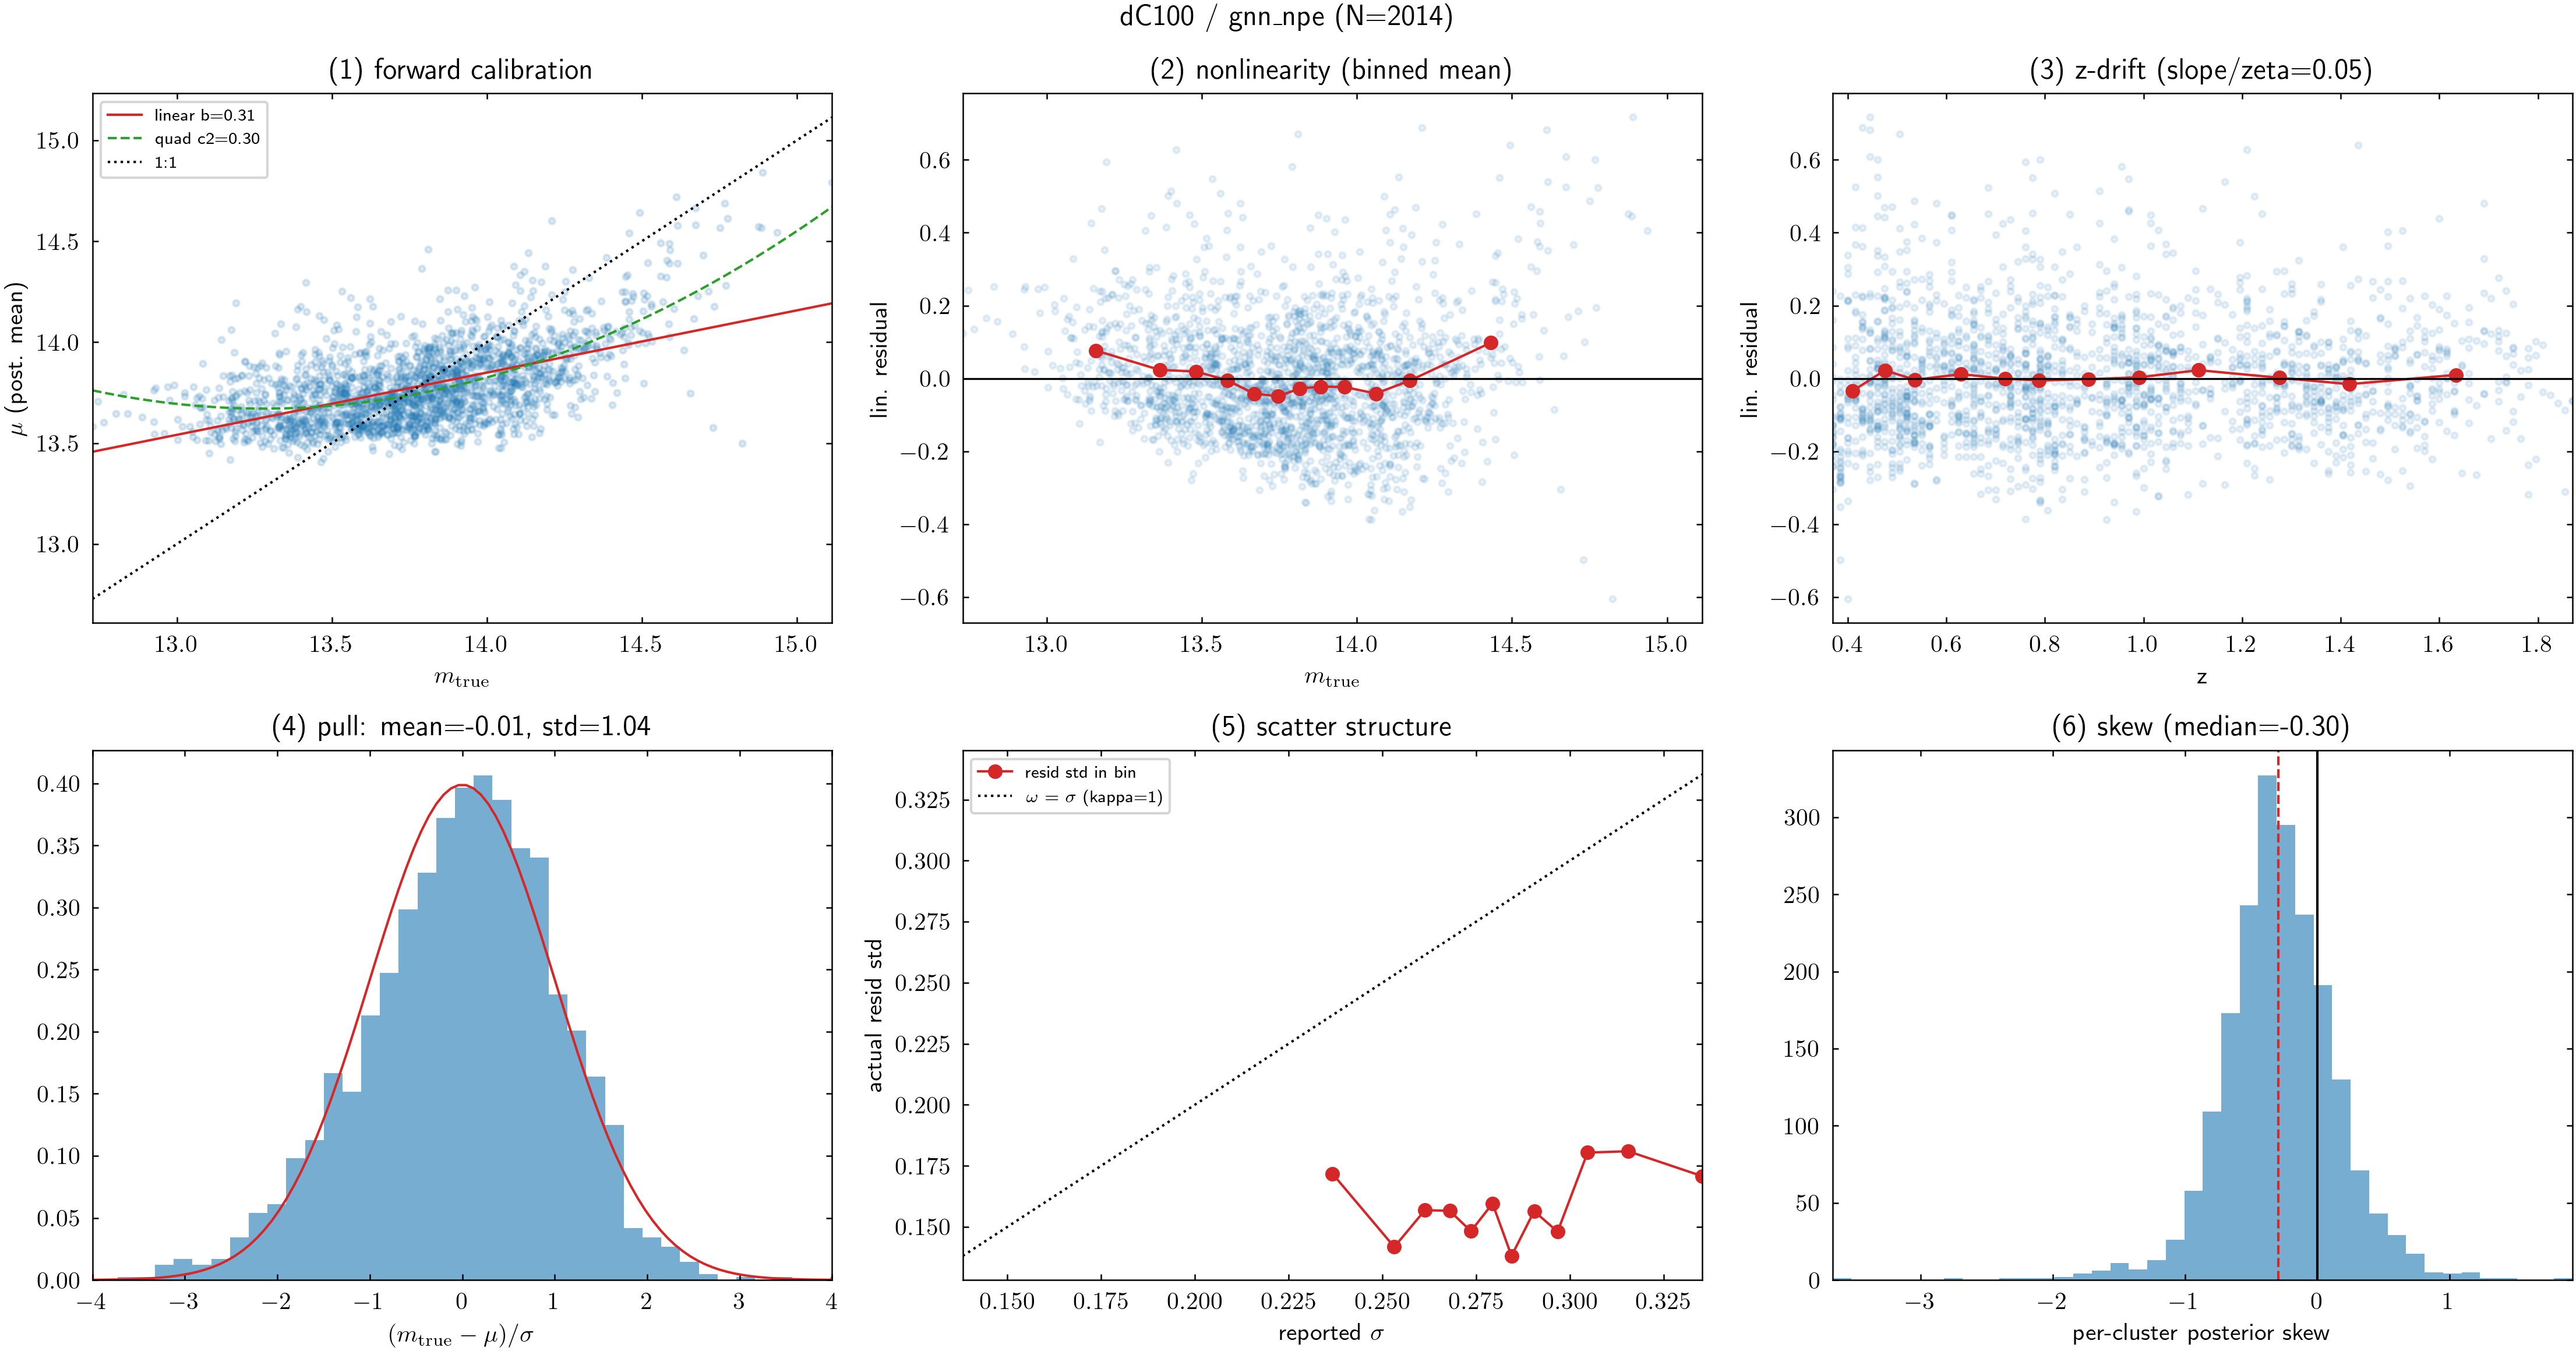

In [15]:
results['gnn_npe'] = diagnose('dC100', 'gnn_npe')

In [ ]:
# Summary table of the four assumptions
import pandas as pd
df = pd.DataFrame(results).T[
    ['N', 'b_fwd', 'quad_c2', 'z_slope', 'pull_mean', 'pull_std', 'skew_med']]
print(df.to_string(float_format=lambda x: f'{x:.3f}'))
print()
print("Ideal (assumptions hold): b_fwd in (0,1], quad_c2~0 (linear),")
print("z_slope~0 (no z-drift), pull_mean~0 & pull_std~1 (calibrated widths),")
print("skew_med~0 (Gaussian posteriors).")

            N b_fwd quad_c2 z_slope pull_mean pull_std skew_med
msig     2011 0.003  -0.013   0.003     0.000    1.002    0.000
mamp     1529 0.142   0.271  -2.363    -1.439    2.416    0.007
gnn_npe  2014 0.308   0.297   0.046    -0.014    1.039   -0.296

Ideal (assumptions hold): b_fwd in (0,1], quad_c2~0 (linear),
z_slope~0 (no z-drift), pull_mean~0 & pull_std~1 (calibrated widths),
skew_med~0 (Gaussian posteriors).
